# Kernel gaussiana

Este tipo de regresion nos ayudar de una forma mas dinamica y sin la necesidad de especificar los 
vecinos cual es el valor de la distribucion con respecto a todos los valores, recordemos que el knn con el 
numero de vecinos que queremos tomar miramos la distancia y podemos calcular cual es el proximo valor.

en este caso la distribucion gauss kernel es un poco mas diferente, aca con todos los valores tratamos de 
encontrar la funcion que pueda darnos la distancia promedio de todos los valores de a muestra, una vez que esta 
es contrada entonces podemos decir que esa funcion es la mejor para predecir cosas

## Kernel a mano

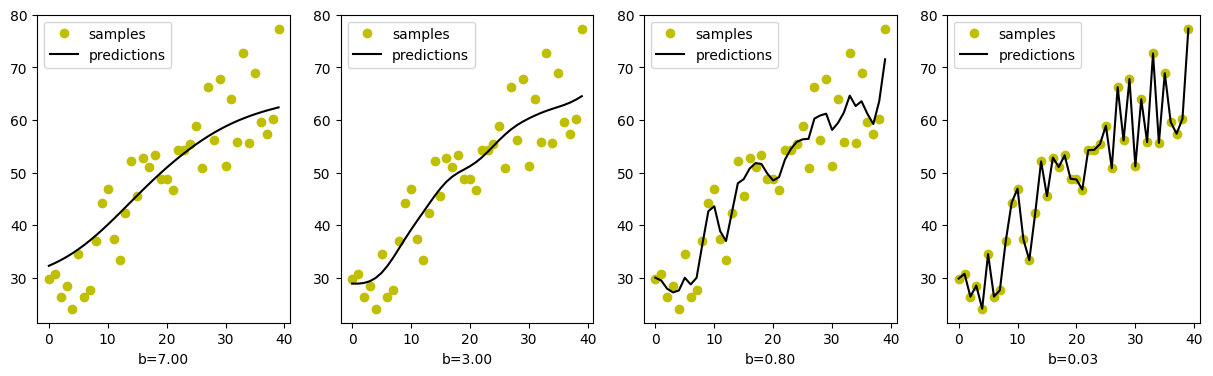

In [8]:
import matplotlib.pyplot as plt
import random
import math

# creamos los ejemplos que queremos analizar

X = list(range(40))

y = []

for i in range(len(X)):
    y.append(20 + X[i] + random.random()*20)


fig,axs = plt.subplots(1,4,figsize=(15,4))

# Zi = (Xi - U)/B = (Xi - x)/B
# x = media de la distirbucion
# b = varianza


# creamos una funcion de kernel gaussian
def Kernel_function(b, X, y,x,figure):
    y_predcition = 0

    for i in range(len(X)):
        y_predcition += w(b,i,X,x)*y[i]
    y_predcition /= len(X)
    return y_predcition

def w(b,i,X,x):
    denom = 0;
    for j in range(len(X)):
        denom += kernel((X[j]-x)/b)
    
    return (len(X)*kernel((X[i]-x)/b))/denom

def kernel(z):
    return math.exp(-(z*z)/2)/math.sqrt(2*math.pi)

def plot(fig,X,y,parameters,label):
    axs[fig].plot(X,y,parameters,label=label)
    axs[fig].legend(); axs[fig].grid()
    return

for b,fig in zip([7,3,0.8,0.03],range(4)):
    y_prediction = []
    for x in range(len(X)):
        y_prediction.append(Kernel_function(b,X,y,x,0))
    plot(fig,X,y,'yo','samples')
    plot(fig,X,y_prediction,"k-",'predictions')
    axs[fig].set_xlabel('b='+'{:4.2f}'.format(b))

plt.show()

## Kernel Gauss con Scikit

c:\Users\juanc\OneDrive\Documentos\IA Resource\UdemyIAResource\MachineLearningModels\venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


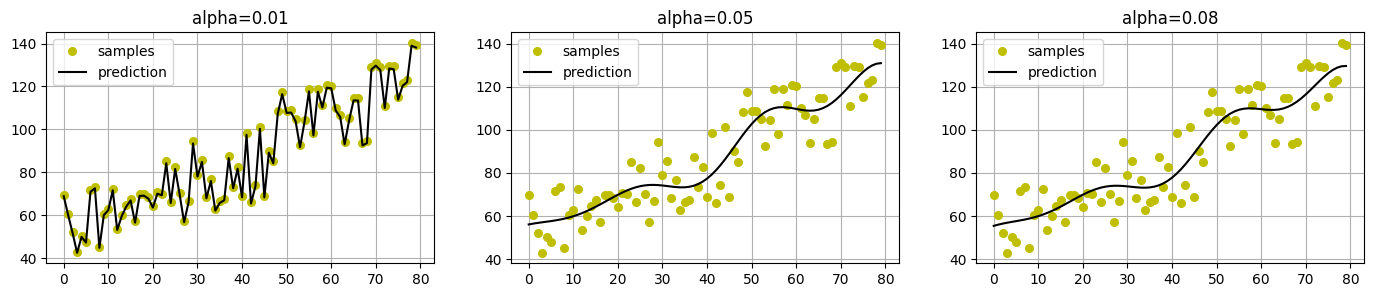

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF


y = []
X = np.array(list(range(80)))[:, np.newaxis]

for i in range(len(X)):
    y.append(20+X[i]+ random.random()*50)

kernel = RBF(10,(0.01,1e2))

fig,axs = plt.subplots(1,3, figsize=(17,3))

for i, alpha in zip([0,1,2],[0.01,0.05,0.08]):
    gp = GaussianProcessRegressor(alpha=alpha,kernel=kernel)
    gp.fit(X,y)
    y_pred, sigma = gp.predict(X,return_std=True)

    axs[i].plot(X,y,'y.',markersize=11,label='samples')
    axs[i].plot(X,y_pred, 'k-',label='prediction')
    axs[i].legend()
    axs[i].set_title('alpha='+str(alpha))
    axs[i].grid()

plt.show()